**Lab 2 – Multi-Class Human Activity Recognition & Quantization Scheme Analysis**


**Workflow**

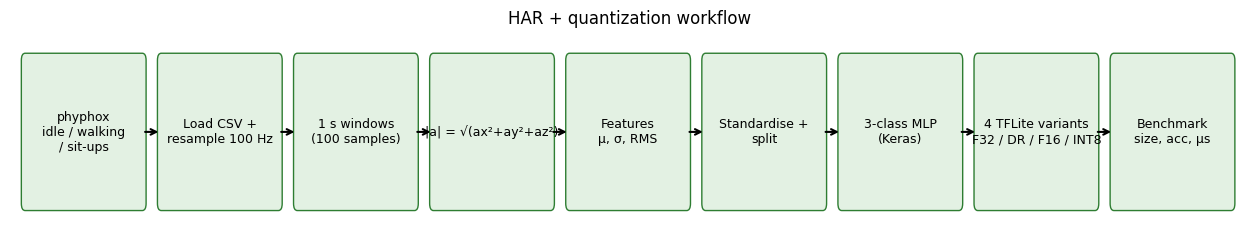

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

steps = ["phyphox\nidle / walking\n/ sit-ups", "Load CSV +\nresample 100 Hz", "1 s windows\n(100 samples)",
         "|a| = √(ax²+ay²+az²)", "Features\nμ, σ, RMS", "Standardise +\nsplit", "3-class MLP\n(Keras)",
         "4 TFLite variants\nF32 / DR / F16 / INT8", "Benchmark\nsize, acc, µs"]
fig, ax = plt.subplots(figsize=(16, 2.6))
ax.axis("off")
w, gap = 1.55, 0.25
for i, s in enumerate(steps):
    x = i * (w + gap)
    ax.add_patch(FancyBboxPatch((x, 0), w, 1, boxstyle="round,pad=0.05", fc="#e3f1e3", ec="#2e7d32"))
    ax.text(x + w/2, 0.5, s, ha="center", va="center", fontsize=9)
    if i < len(steps) - 1:
        ax.annotate("", xy=(x + w + gap, 0.5), xytext=(x + w, 0.5), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.set_xlim(-0.2, len(steps) * (w + gap)); ax.set_ylim(-0.2, 1.2)
plt.title("HAR + quantization workflow")
plt.savefig("workflow_lab2.png", dpi=150, bbox_inches="tight")
plt.show()

**Setup and configuration**

In [2]:
import os, time, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import tensorflow as tf

try:
    from ai_edge_litert.interpreter import Interpreter
except ImportError:
    Interpreter = tf.lite.Interpreter

np.random.seed(42); tf.random.set_seed(42)
print("TensorFlow", tf.__version__)

FILES   = {"Idle": "idle.csv", "Walking": "walking.csv", "Sit-ups": "situps.csv"}
CLASSES = list(FILES.keys())
FS      = 100
WIN     = 100
STEP    = 100
TRIM_S  = 2

TensorFlow 2.20.0


**Data acquisition (upload phyphox CSVs)**

In [5]:
missing = [f for f in FILES.values() if not os.path.exists(f)]
if missing:
    try:
        from google.colab import files
        print("Upload:", missing, "(rename after upload if needed)")
        files.upload()
    except Exception as e:
        print("Not running in Colab / no upload:", type(e).__name__)
for c, f in FILES.items():
    print(f"{c:8s} {f:12s} found={os.path.exists(f)}")

Upload: ['idle.csv', 'walking.csv', 'situps.csv'] (rename after upload if needed)


Saving walking.csv to walking.csv
Saving idle.csv to idle.csv
Saving situps.csv to situps.csv
Idle     idle.csv     found=True
Walking  walking.csv  found=True
Sit-ups  situps.csv   found=True


In [6]:
raw = {c: pd.read_csv(f, sep=None, engine="python") for c, f in FILES.items()}
for c in CLASSES:
    d = raw[c]
    print(f"{c:8s} samples={len(d):6d}  duration={d.iloc[-1, 0]:.1f} s  fs≈{1/np.median(np.diff(d.iloc[:, 0])):.0f} Hz")

Idle     samples= 97397  duration=194.7 s  fs≈500 Hz
Walking  samples= 93205  duration=186.4 s  fs≈500 Hz
Sit-ups  samples= 94656  duration=189.3 s  fs≈500 Hz


**Preprocessing – resample to 100 Hz and compute |a|**

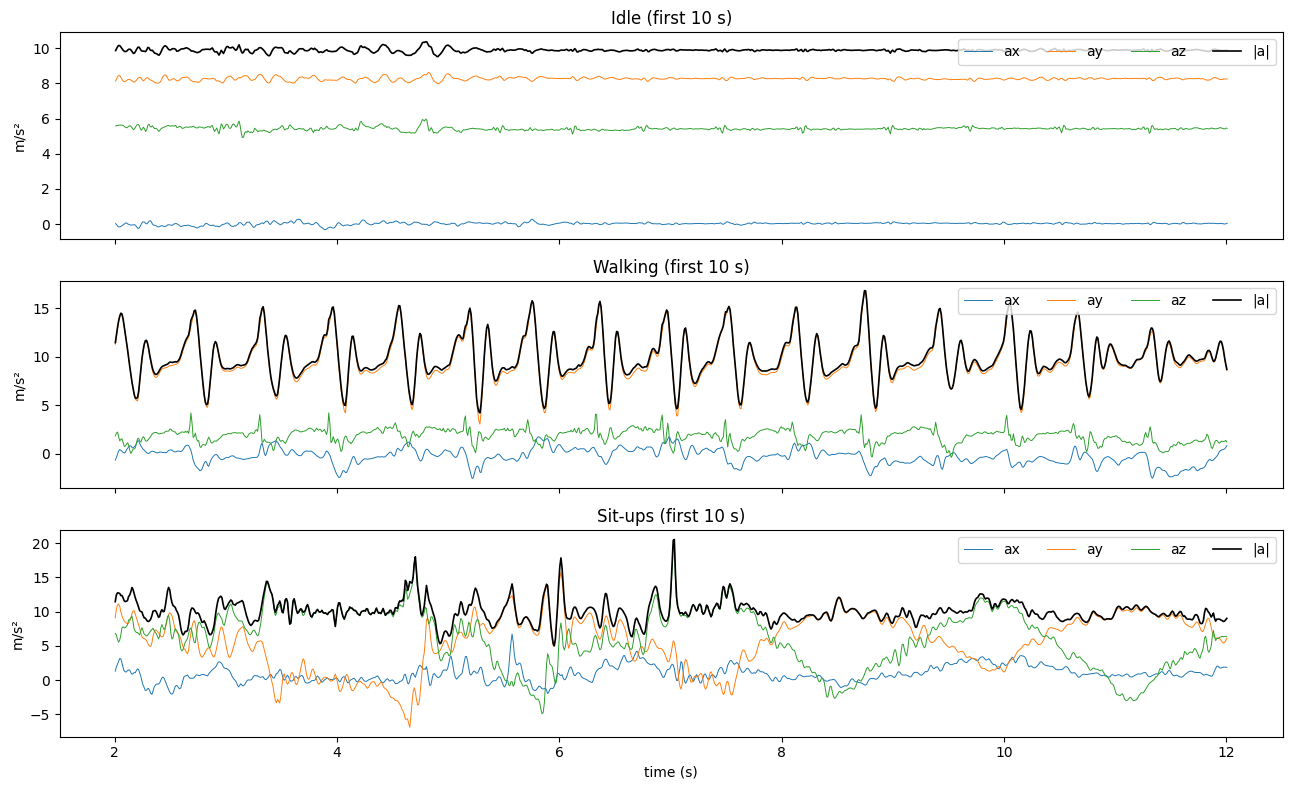

In [7]:
def preprocess(df):
    d = df.iloc[:, :4].copy(); d.columns = ["t", "ax", "ay", "az"]
    d = d.apply(pd.to_numeric, errors="coerce").dropna().sort_values("t").drop_duplicates("t")
    t = np.arange(d.t.iloc[0] + TRIM_S, d.t.iloc[-1] - TRIM_S, 1/FS)
    out = pd.DataFrame({"t": t, **{k: np.interp(t, d.t, d[k]) for k in ["ax", "ay", "az"]}})
    out["amag"] = np.sqrt(out.ax**2 + out.ay**2 + out.az**2)
    return out

sig = {c: preprocess(raw[c]) for c in CLASSES}

fig, axs = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, c in zip(axs, CLASSES):
    s = sig[c][sig[c].t < sig[c].t.iloc[0] + 10]
    for k in ["ax", "ay", "az"]: ax.plot(s.t, s[k], lw=0.7, label=k)
    ax.plot(s.t, s.amag, "k", lw=1.2, label="|a|")
    ax.set_title(f"{c} (first 10 s)"); ax.set_ylabel("m/s²"); ax.legend(ncol=4, loc="upper right")
axs[-1].set_xlabel("time (s)"); plt.tight_layout(); plt.show()

**Windowing and feature extraction (μ, σ, RMS)**

In [8]:
def window_features(a):
    feats = []
    for s in range(0, len(a) - WIN + 1, STEP):
        w = a[s:s+WIN]; N = len(w)
        mu = np.sum(w) / N
        sigma = np.sqrt(np.sum((w - mu)**2) / N)
        rms = np.sqrt(np.sum(w**2) / N)
        feats.append([mu, sigma, rms])
    return np.array(feats, dtype=np.float32)

Xs, ys = [], []
for i, c in enumerate(CLASSES):
    f = window_features(sig[c].amag.values)
    Xs.append(f); ys.append(np.full(len(f), i))
X = np.vstack(Xs); y = np.concatenate(ys)
feat_df = pd.DataFrame(X, columns=["mean", "std", "rms"]); feat_df["activity"] = [CLASSES[i] for i in y]
feat_df.to_csv("har_features.csv", index=False)
print("Feature matrix:", X.shape); print(feat_df.activity.value_counts())
feat_df.groupby("activity").agg(["mean", "std"]).round(3)

Feature matrix: (557, 3)
activity
Idle       190
Sit-ups    185
Walking    182
Name: count, dtype: int64


mean           std            rms       
           mean    std   mean    std    mean    std
activity                                           
Idle      9.880  0.005  0.046  0.034   9.881  0.005
Sit-ups   9.946  0.395  0.879  0.475   9.994  0.428
Walking   9.893  0.165  1.538  0.459  10.022  0.191

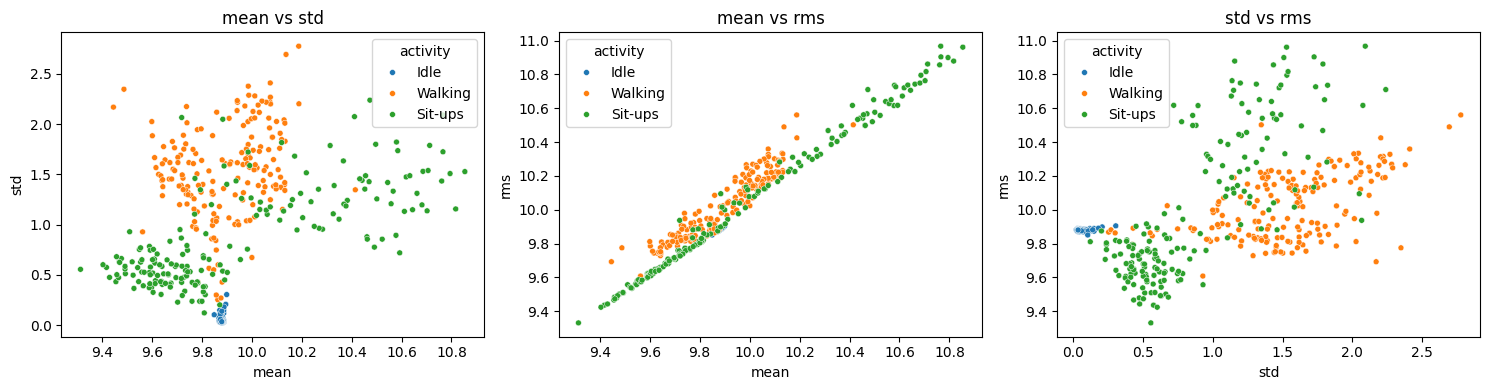

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, (a, b) in zip(axs, [("mean", "std"), ("mean", "rms"), ("std", "rms")]):
    sns.scatterplot(data=feat_df, x=a, y=b, hue="activity", s=18, ax=ax)
    ax.set_title(f"{a} vs {b}")
plt.tight_layout(); plt.show()

**Split and normalise**

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr).astype(np.float32)
X_te_s = scaler.transform(X_te).astype(np.float32)
print("Train:", X_tr_s.shape, "Test:", X_te_s.shape)

Train: (417, 3) Test: (140, 3)


**Baseline 3-class MLP**

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,435 (9.51 KB)

 Trainable params: 2,435 (9.51 KB)

 Non-trainable params: 0 (0.00 B)

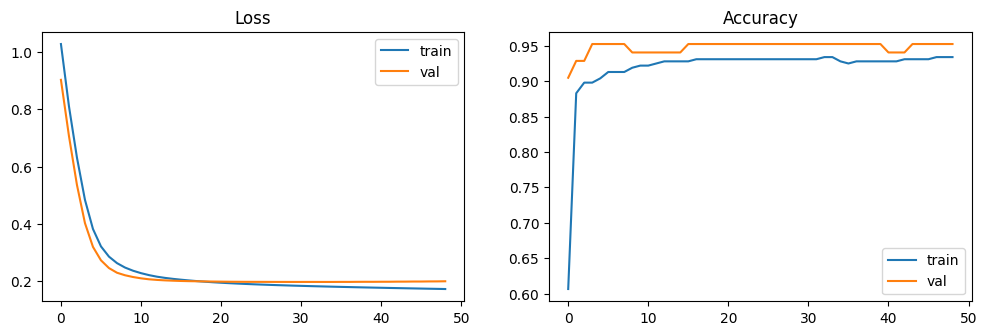

Keras test accuracy: 91.43 %
              precision    recall  f1-score   support

        Idle       0.94      1.00      0.97        48
     Walking       0.88      0.91      0.89        46
     Sit-ups       0.93      0.83      0.87        46

    accuracy                           0.91       140
   macro avg       0.91      0.91      0.91       140
weighted avg       0.91      0.91      0.91       140



In [11]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax"),
])
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

hist = model.fit(X_tr_s, y_tr, validation_split=0.2, epochs=100, batch_size=16, verbose=0,
                 callbacks=[tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)])

fig, axs = plt.subplots(1, 2, figsize=(12, 3.5))
axs[0].plot(hist.history["loss"], label="train"); axs[0].plot(hist.history["val_loss"], label="val"); axs[0].set_title("Loss"); axs[0].legend()
axs[1].plot(hist.history["accuracy"], label="train"); axs[1].plot(hist.history["val_accuracy"], label="val"); axs[1].set_title("Accuracy"); axs[1].legend()
plt.show()

p_keras = model.predict(X_te_s, verbose=0).argmax(1)
print("Keras test accuracy:", round(accuracy_score(y_te, p_keras) * 100, 2), "%")
print(classification_report(y_te, p_keras, target_names=CLASSES))
model.save("har_mlp.keras")

**TFLite conversion – four variants**

In [12]:
tf.get_logger().setLevel("ERROR")

def rep_data():
    for i in range(min(300, len(X_tr_s))):
        yield [X_tr_s[i:i+1]]

def convert(kind):
    cv = tf.lite.TFLiteConverter.from_keras_model(model)
    if kind == "dynamic":
        cv.optimizations = [tf.lite.Optimize.DEFAULT]
    elif kind == "float16":
        cv.optimizations = [tf.lite.Optimize.DEFAULT]
        cv.target_spec.supported_types = [tf.float16]
    elif kind == "int8":
        cv.optimizations = [tf.lite.Optimize.DEFAULT]
        cv.representative_dataset = rep_data
        cv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        cv.inference_input_type = tf.int8
        cv.inference_output_type = tf.int8
    return cv.convert()

VARIANTS = {
    "A: Baseline (Float32)": ("float32", "Float32",                    "har_A_float32.tflite"),
    "B: Dynamic Range":      ("dynamic", "Weights int8, Act float32",  "har_B_dynamic.tflite"),
    "C: Float16":            ("float16", "Float16",                    "har_C_float16.tflite"),
    "D: Full Integer (PTQ)": ("int8",    "Weights int8, Act int8",     "har_D_int8.tflite"),
}
for name, (kind, _, path) in VARIANTS.items():
    open(path, "wb").write(convert(kind))
    print(f"{name:25s} -> {path:22s} {os.path.getsize(path)/1024:6.2f} KB")

Saved artifact at '/tmp/tmpv1e_6qg0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  137689997158224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137689996845392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137689996845776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137689996843856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137689996844048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137689996843472: TensorSpec(shape=(), dtype=tf.resource, name=None)
A: Baseline (Float32)     -> har_A_float32.tflite    11.56 KB
Saved artifact at '/tmp/tmpoejw3_wy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [13]:
for name, (_, _, path) in VARIANTS.items():
    itp = Interpreter(model_path=path); itp.allocate_tensors()
    dtypes = pd.Series([d["dtype"].__name__ for d in itp.get_tensor_details()]).value_counts().to_dict()
    print(f"{name:25s} in={itp.get_input_details()[0]['dtype'].__name__:8s} out={itp.get_output_details()[0]['dtype'].__name__:8s} tensors={dtypes}")

A: Baseline (Float32)     in=float32  out=float32  tensors={'float32': 11}
B: Dynamic Range          in=float32  out=float32  tensors={'float32': 10, 'int8': 1}
C: Float16                in=float32  out=float32  tensors={'float32': 11, 'float16': 6}
D: Full Integer (PTQ)     in=int8     out=int8     tensors={'int8': 8, 'int32': 3}


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

**Benchmarking – size, accuracy, memory reduction, latency**

In [14]:
def evaluate(path, Xs, reps=3):
    itp = Interpreter(model_path=path, num_threads=1); itp.allocate_tensors()
    inp, out = itp.get_input_details()[0], itp.get_output_details()[0]
    preds, times = [], []
    for x in Xs:
        x = x[None, :]
        if inp["dtype"] == np.int8:
            s, z = inp["quantization"]; x = np.round(x / s + z).clip(-128, 127).astype(np.int8)
        itp.set_tensor(inp["index"], x)
        best = 1e18
        for _ in range(reps):
            t0 = time.perf_counter_ns(); itp.invoke(); best = min(best, time.perf_counter_ns() - t0)
        times.append(best / 1e3)
        o = itp.get_tensor(out["index"])
        preds.append(int(np.argmax(o)))
    return np.array(preds), float(np.mean(times))

base_kb = os.path.getsize(VARIANTS["A: Baseline (Float32)"][2]) / 1024
rows, preds_all = [], {}
for name, (_, dtype, path) in VARIANTS.items():
    p, us = evaluate(path, X_te_s)
    preds_all[name] = p
    kb = os.path.getsize(path) / 1024
    rows.append([name, dtype, round(kb, 2), round(accuracy_score(y_te, p) * 100, 2), round((1 - kb / base_kb) * 100, 1), round(us, 2)])

bench = pd.DataFrame(rows, columns=["Quantization Scheme", "Target Data Type", "Model Size (KB)", "Accuracy (%)", "Memory Reduction (%)", "Avg Latency (µs)"])
bench.to_csv("quantization_benchmark.csv", index=False)
bench

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

,Quantization Scheme,Target Data Type,Model Size (KB),Accuracy (%),Memory Reduction (%),Avg Latency (µs)
0,A: Baseline (Float32),Float32,11.56,91.43,0.0,2.39
1,B: Dynamic Range,"Weights int8, Act float32",5.98,91.43,48.3,1.86
2,C: Float16,Float16,7.57,91.43,34.6,1.76
3,D: Full Integer (PTQ),"Weights int8, Act int8",7.32,91.43,36.7,1.90


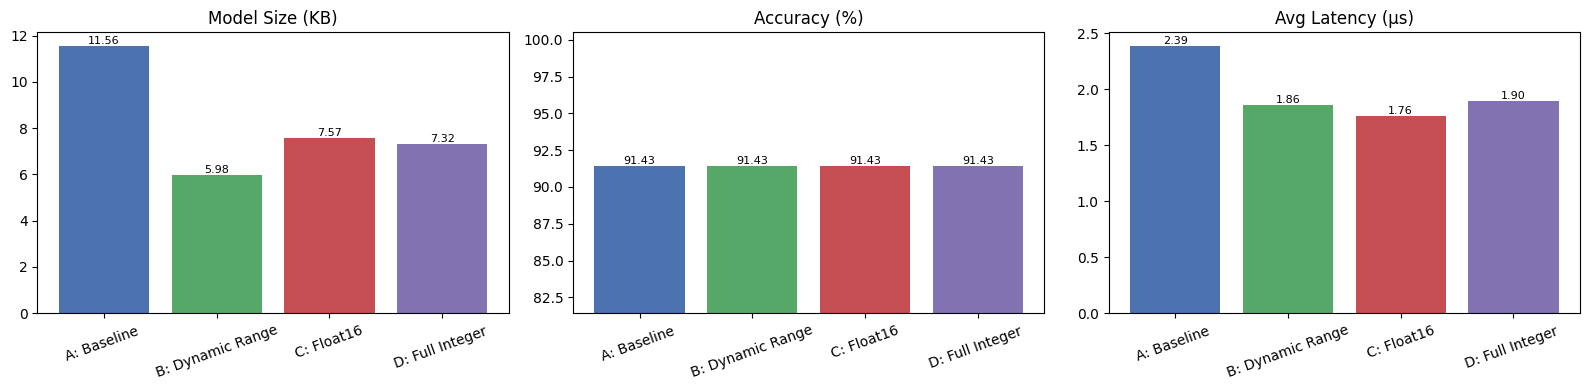

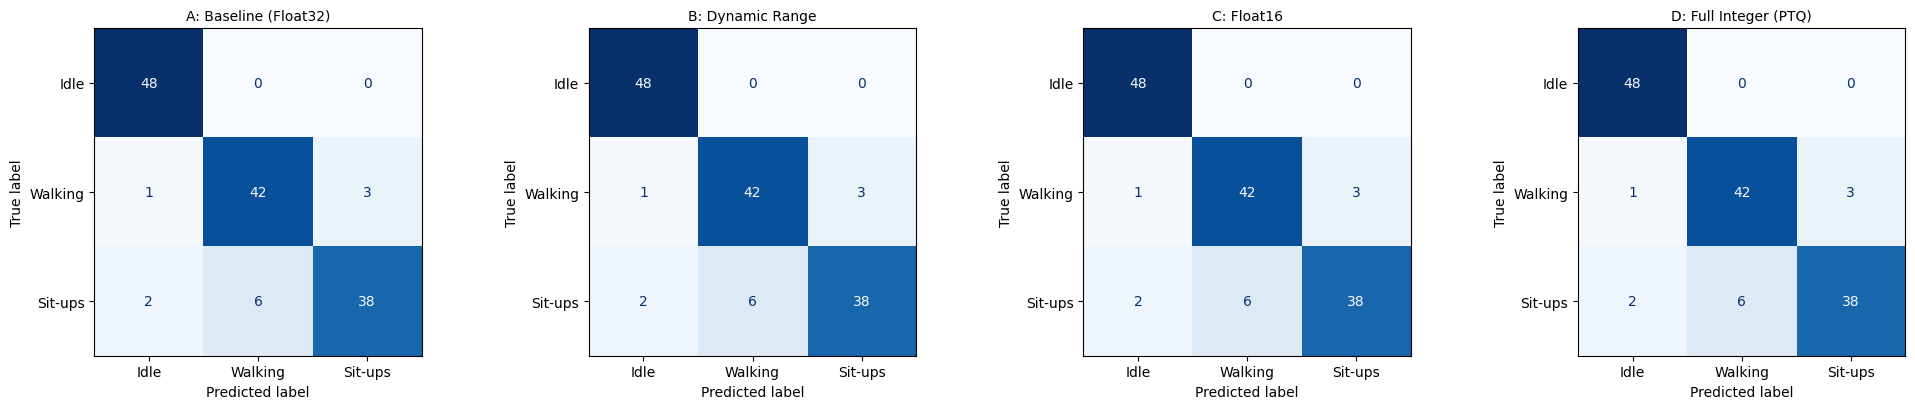

In [15]:
colors = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
short = [n.split(":")[0] + ":" + n.split(":")[1].split("(")[0] for n in bench["Quantization Scheme"]]
for ax, col in zip(axs, ["Model Size (KB)", "Accuracy (%)", "Avg Latency (µs)"]):
    bars = ax.bar(short, bench[col], color=colors); ax.set_title(col); ax.tick_params(axis="x", rotation=20)
    ax.bar_label(bars, fmt="%.2f", fontsize=8)
axs[1].set_ylim(max(0, bench["Accuracy (%)"].min() - 10), 100.5)
plt.tight_layout(); plt.savefig("quantization_benchmark.png", dpi=150); plt.show()

fig, axs = plt.subplots(1, 4, figsize=(20, 4.2))
for ax, (name, p) in zip(axs, preds_all.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_te, p), display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.savefig("confusion_matrices_lab2.png", dpi=150); plt.show()

In [16]:
for name, p in preds_all.items():
    print(f"{name:25s} agreement with Float32: {np.mean(p == preds_all['A: Baseline (Float32)'])*100:6.2f} %")

A: Baseline (Float32)     agreement with Float32: 100.00 %
B: Dynamic Range          agreement with Float32: 100.00 %
C: Float16                agreement with Float32: 100.00 %
D: Full Integer (PTQ)     agreement with Float32: 100.00 %


**Export Full-Integer model as C array (TFLite Micro)**

In [17]:
data = open("har_D_int8.tflite", "rb").read()
hexs = ", ".join(f"0x{b:02x}" for b in data)
open("har_model_int8.h", "w").write(
    f"// Full-integer HAR model\nalignas(16) const unsigned char har_model[] = {{ {hexs} }};\nconst unsigned int har_model_len = {len(data)};\n")
itp = Interpreter(model_path="har_D_int8.tflite"); itp.allocate_tensors()
print("Input quant (scale, zp):", itp.get_input_details()[0]["quantization"])
print("Scaler mean:", np.round(scaler.mean_, 4), "std:", np.round(scaler.scale_, 4))
print("Header size:", round(os.path.getsize("har_model_int8.h") / 1024, 2), "KB")

Input quant (scale, zp): (0.02376381680369377, -29)
Scaler mean: [9.9101 0.8136 9.9685] std: [0.254  0.7175 0.2823]
Header size: 44.04 KB


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


**Report summary**

In [18]:
print("=" * 60)
print("QUANTIZATION BENCHMARK")
print("=" * 60)
print(f"Windows per class: {feat_df.activity.value_counts().to_dict()}")
print(f"Keras MLP accuracy: {accuracy_score(y_te, p_keras)*100:.2f} %  | params: {model.count_params()}")
print(bench.to_string(index=False))

QUANTIZATION BENCHMARK
Windows per class: {'Idle': 190, 'Sit-ups': 185, 'Walking': 182}
Keras MLP accuracy: 91.43 %  | params: 2435
  Quantization Scheme          Target Data Type  Model Size (KB)  Accuracy (%)  Memory Reduction (%)  Avg Latency (µs)
A: Baseline (Float32)                   Float32            11.56         91.43                   0.0              2.39
     B: Dynamic Range Weights int8, Act float32             5.98         91.43                  48.3              1.86
           C: Float16                   Float16             7.57         91.43                  34.6              1.76
D: Full Integer (PTQ)    Weights int8, Act int8             7.32         91.43                  36.7              1.90


**Analysis – why Full Integer quantization for microcontrollers**

- Size: Dynamic range and full-integer store weights as int8, roughly 4× smaller than float32 for the weight part; Float16 halves it. For a very small MLP the fixed flatbuffer overhead (metadata, op table) is a large share of the file, so the percentage reduction looks smaller than 75%.
- Accuracy: With only three well-separated features (μ, σ, RMS of |a|) all four variants retain nearly the same accuracy; int8 calibration with a representative dataset keeps the quantization error small.
- Latency on a PC: differences are a few microseconds and can go either way because desktop CPUs have fast float units and the interpreter overhead dominates. On an MCU the gap is much larger.
- Why full integer is required on MCUs:
  - Many Cortex-M0/M0+/M3 cores have no FPU, so float32 or float16 math is emulated in software and is very slow.
  - Dynamic range quantization still produces float activations and de-quantizes weights at run time, so it still needs float kernels.
  - Float16 is mainly a GPU format; most MCUs cannot execute fp16 natively and convert back to float32.
  - TFLite Micro and CMSIS-NN / NPUs (Ethos-U, Edge TPU) provide optimized int8-only kernels (SIMD MAC instructions).
  - int8 activations cut the RAM tensor arena by ~4×, which matters with 16–256 KB of SRAM, and integer ops use less energy per inference, extending wearable battery life.

**Download deliverables**

In [ ]:
out = list(FILES.values()) + ["har_features.csv", "har_mlp.keras", "har_model_int8.h", "quantization_benchmark.csv",
       "quantization_benchmark.png", "confusion_matrices_lab2.png", "workflow_lab2.png"] + [v[2] for v in VARIANTS.values()]
with zipfile.ZipFile("lab2_deliverables.zip", "w") as z:
    for f in out:
        if os.path.exists(f): z.write(f)
print("Saved lab2_deliverables.zip")
try:
    from google.colab import files; files.download("lab2_deliverables.zip")
except Exception:
    pass

Saved lab2_deliverables.zip
